In [1]:
import pandas as pd

In [2]:
movies = pd.read_csv(r'C:\Users\leish\OneDrive\Desktop\DS_Genai\Proof of Concept\Pandas\imdb_movie_analysis\archive\movie.csv')

In [3]:
movies.shape

(27278, 3)

In [4]:
movies.columns

Index(['movieId', 'title', 'genres'], dtype='str')

In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
tags = pd.read_csv(r'C:\Users\leish\OneDrive\Desktop\DS_Genai\Proof of Concept\Pandas\imdb_movie_analysis\archive\tag.csv')

In [7]:
tags.shape

(465564, 4)

In [8]:
tags.columns

Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='str')

In [9]:
ratings = pd.read_csv(r'C:\Users\leish\OneDrive\Desktop\DS_Genai\Proof of Concept\Pandas\imdb_movie_analysis\archive\rating.csv')

In [10]:
ratings.shape

(20000263, 4)

In [11]:
ratings.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')

In [12]:
print(movies.columns)
print(tags.columns)
print(ratings.columns)

Index(['movieId', 'title', 'genres'], dtype='str')
Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='str')
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')


In [13]:
del ratings['timestamp']
del tags['timestamp']

In [14]:
print(movies.columns)
print(tags.columns)
print(ratings.columns)

Index(['movieId', 'title', 'genres'], dtype='str')
Index(['userId', 'movieId', 'tag'], dtype='str')
Index(['userId', 'movieId', 'rating'], dtype='str')


In [15]:
row_0 = tags.iloc[0]

In [16]:
row_0.index

Index(['userId', 'movieId', 'tag'], dtype='str')

In [17]:
print(row_0)

userId              18
movieId           4141
tag        Mark Waters
Name: 0, dtype: object


In [18]:
row_0['userId']

np.int64(18)

In [19]:
'rating' in row_0

False

Data Frames

In [20]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [21]:
tags.index

RangeIndex(start=0, stop=465564, step=1)

In [22]:
tags.columns

Index(['userId', 'movieId', 'tag'], dtype='str')

In [23]:
tags.iloc[[0,11,500]]

,userId,movieId,tag
0,18,4141,Mark Waters
11,65,1783,noir thriller
500,342,55908,entirely dialogue


DESCRIPTIVE STATISTICS

In [26]:
ratings['rating'].describe()

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [27]:
ratings.describe()

,userId,movieId,rating
count,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00
std,4.003863e+04,1.978948e+04,1.051989e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,3.439500e+04,9.020000e+02,3.000000e+00
50%,6.914100e+04,2.167000e+03,3.500000e+00
75%,1.036370e+05,4.770000e+03,4.000000e+00
max,1.384930e+05,1.312620e+05,5.000000e+00


In [28]:
ratings['rating'].mean()

np.float64(3.5255285642993797)

In [29]:
ratings.mean()

userId     69045.872583
movieId     9041.567330
rating         3.525529
dtype: float64

In [30]:
ratings['rating'].max()

np.float64(5.0)

In [31]:
ratings['rating'].min()

np.float64(0.5)

In [32]:
ratings['rating'].std()

np.float64(1.0519889192942418)

In [33]:
ratings['rating'].mode()

0    4.0
Name: rating, dtype: float64

In [34]:
ratings.corr()

,userId,movieId,rating
userId,1.000000,-0.000850,0.001175
movieId,-0.000850,1.000000,0.002606
rating,0.001175,0.002606,1.000000


In [35]:
filter1 = ratings['rating'] > 10
print(filter1)
filter1.any()

0           False
1           False
2           False
3           False
4           False
            ...  
20000258    False
20000259    False
20000260    False
20000261    False
20000262    False
Name: rating, Length: 20000263, dtype: bool


np.False_

In [37]:
filter2 = ratings['rating'] > 0
filter2.all()

np.True_

DATA CLEANING: HANDLING MISSING DATA

In [38]:
movies.shape

(27278, 3)

In [39]:
movies.isnull().any().any()

np.False_

In [40]:
ratings.shape

(20000263, 3)

In [41]:
ratings.isnull().any().any()

np.False_

In [42]:
tags.shape

(465564, 3)

In [43]:
tags.isnull().any().any()

np.True_

In [44]:
tags = tags.dropna()

In [45]:
tags.isnull().any().any()

np.False_

In [46]:
tags.shape

(465548, 3)

DATA VISUALIZATION

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

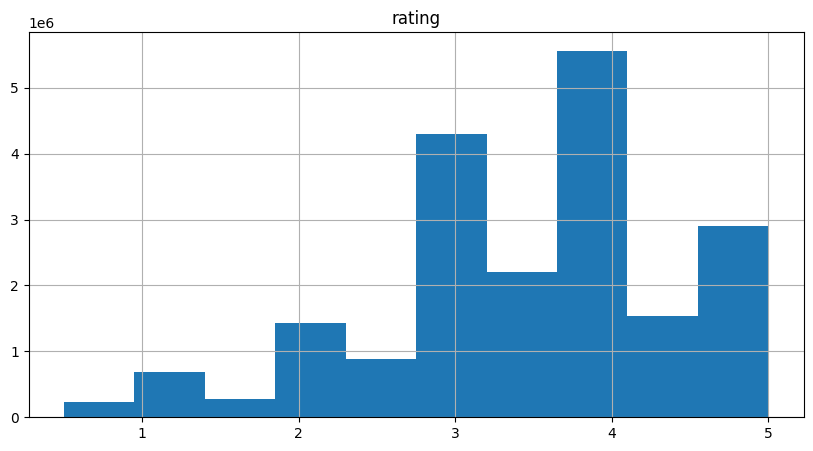

In [47]:
%matplotlib inline

ratings.hist(column='rating', figsize=(10,5))

<Axes: >

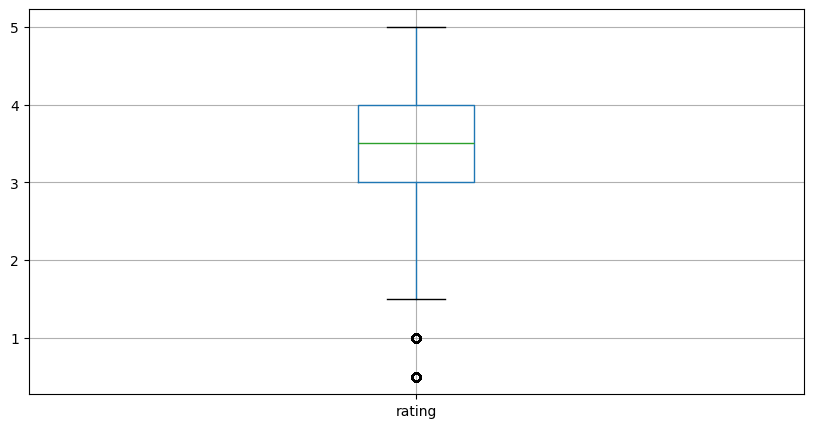

In [48]:
ratings.boxplot(column='rating', figsize=(10,5))

SLICING OUT COLUMNS

In [49]:
tags['tag'].head()

0      Mark Waters
1        dark hero
2        dark hero
3    noir thriller
4        dark hero
Name: tag, dtype: str

In [50]:
movies[['title', 'genres']].head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [51]:
ratings[-10:]

,userId,movieId,rating
20000253,138493,60816,4.5
20000254,138493,61160,4.0
20000255,138493,65682,4.5
20000256,138493,66762,4.5
20000257,138493,68319,4.5
20000258,138493,68954,4.5
20000259,138493,69526,4.5
20000260,138493,69644,3.0
20000261,138493,70286,5.0
20000262,138493,71619,2.5


In [52]:
tag_counts = tags['tag'].value_counts()
tag_counts[-10:]

tag
Roland JoffÃ©                                                           1
Seu Jorge                                                               1
Michel Audiard                                                          1
French film                                                             1
Clouseau                                                                1
Disguises                                                               1
retarted                                                                1
circle k                                                                1
This movie should have been called \\"How Cocaine Ruined Disney\"\""    1
topless scene                                                           1
Name: count, dtype: int64

<Axes: xlabel='tag'>

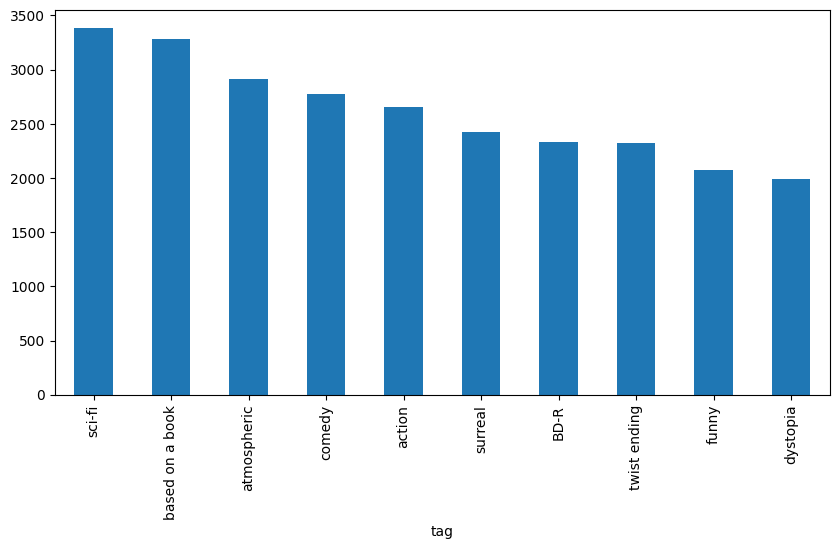

In [53]:
tag_counts[:10].plot(kind='bar', figsize=(10,5))